In [1]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import warnings
warnings.filterwarnings('ignore')

C:\Users\necla\AppData\Roaming\Python\Python39\site-packages\pandas\core\computation\expressions.py:21: UserWarning: Pandas requires version '2.8.4' or newer of 'numexpr' (version '2.8.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
C:\Users\necla\AppData\Roaming\Python\Python39\site-packages\pandas\core\arrays\masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.4' currently installed).
  from pandas.core import (


[*********************100%***********************]  1 of 1 completed


            USDTRY
Date              
2010-01-01  1.4955
2010-02-01  1.5489
2010-03-01  1.5156
2010-04-01  1.4880
2010-05-01  1.5718

Missing values: 0


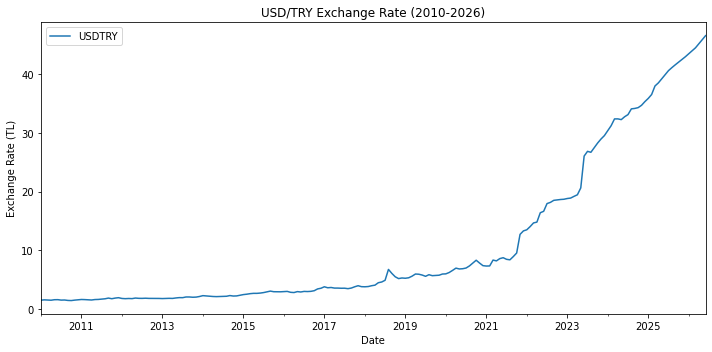

In [2]:
# 1. Fetch monthly USD/TRY data
data_monthly = yf.download("TRY=X", start="2010-01-01", interval="1mo")

# Select only the Close price and make a clean copy (fixes SettingWithCopyWarning)
df_m = data_monthly[['Close']].copy()
df_m.columns = ['USDTRY']
df_m.dropna(inplace=True)

# Set monthly frequency on the index (fixes ValueWarning)
df_m.index = pd.DatetimeIndex(df_m.index).to_period('M').to_timestamp()
df_m = df_m.asfreq('MS')

print(df_m.head())
print(f"\nMissing values: {df_m.isnull().sum().values[0]}")

# Visualize
df_m.plot(figsize=(10, 5), title="USD/TRY Exchange Rate (2010-2026)")
plt.ylabel("Exchange Rate (TL)")
plt.tight_layout()
plt.show()

In [3]:
# 2. Stationarity Test (ADF) on raw series
result = adfuller(df_m['USDTRY'])

print("--- ADF Test (Raw Series) ---")
print(f"ADF Statistic : {result[0]:.4f}")
print(f"p-value       : {result[1]:.4f}")
print("Critical Values:")
for key, value in result[4].items():
    print(f"  {key}: {value:.4f}")
print("\nConclusion: Series is NON-stationary (p > 0.05). Transformation required.")

--- ADF Test (Raw Series) ---
ADF Statistic : 4.4472
p-value       : 1.0000
Critical Values:
  1%: -3.4642
  5%: -2.8764
  10%: -2.5747

Conclusion: Series is NON-stationary (p > 0.05). Transformation required.


--- ADF Test (Log Returns) ---
ADF Statistic : -12.5676
p-value       : 0.0000

Conclusion: Series is STATIONARY (p < 0.05). Ready for ARIMA.


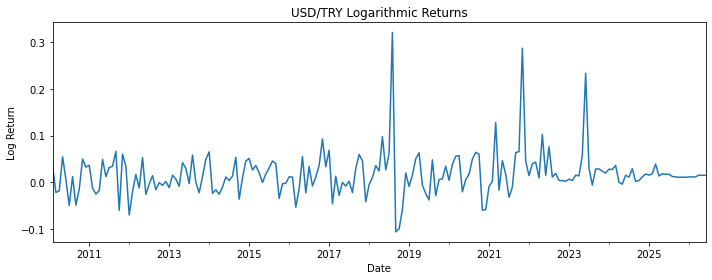

In [4]:
# 3. Logarithmic transformation to achieve stationarity (fixes SettingWithCopyWarning)
df_log = np.log(df_m['USDTRY'] / df_m['USDTRY'].shift(1)).dropna()

# ADF Test on transformed series
result_diff = adfuller(df_log)

print("--- ADF Test (Log Returns) ---")
print(f"ADF Statistic : {result_diff[0]:.4f}")
print(f"p-value       : {result_diff[1]:.4f}")
print("\nConclusion: Series is STATIONARY (p < 0.05). Ready for ARIMA.")

# Visualize stationary series
df_log.plot(figsize=(10, 4), title="USD/TRY Logarithmic Returns")
plt.ylabel("Log Return")
plt.tight_layout()
plt.show()

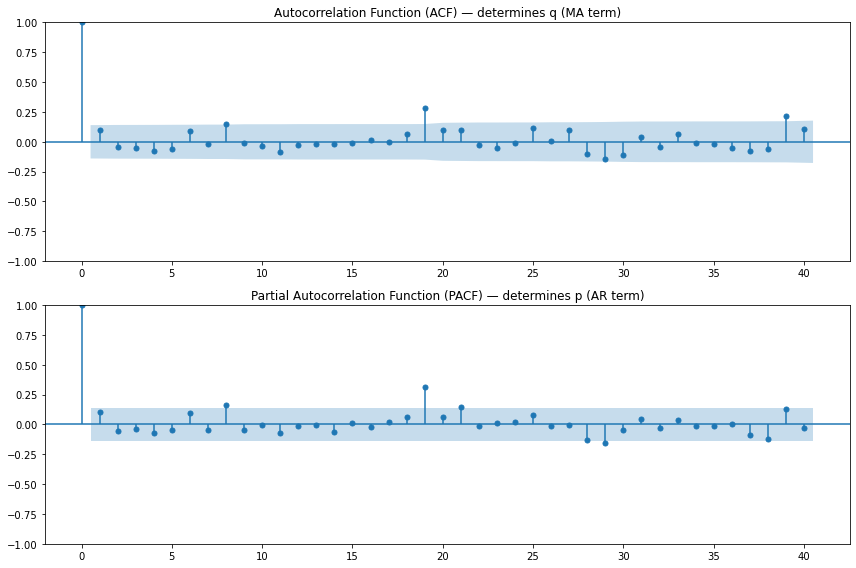

In [5]:
# 4. ACF and PACF plots (to determine p and q parameters)
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8))

plot_acf(df_log, lags=40, ax=ax1)
ax1.set_title('Autocorrelation Function (ACF) — determines q (MA term)')

plot_pacf(df_log, lags=40, ax=ax2)
ax2.set_title('Partial Autocorrelation Function (PACF) — determines p (AR term)')

plt.tight_layout()
plt.show()

In [6]:
# 5. Model selection via AIC
model1 = ARIMA(df_log, order=(1, 0, 1)).fit()
model2 = ARIMA(df_log, order=(2, 0, 2)).fit()

print(f"ARIMA(1,0,1) AIC: {model1.aic:.4f}")
print(f"ARIMA(2,0,2) AIC: {model2.aic:.4f}")
print(f"\nSelected model: ARIMA(1,0,1) — lower AIC is better")

ARIMA(1,0,1) AIC: -636.6484
ARIMA(2,0,2) AIC: -634.8629

Selected model: ARIMA(1,0,1) — lower AIC is better


In [7]:
# 6. Final model summary
model_fit = ARIMA(df_log, order=(1, 0, 1)).fit()
print(model_fit.summary())

                               SARIMAX Results                                
Dep. Variable:                 USDTRY   No. Observations:                  197
Model:                 ARIMA(1, 0, 1)   Log Likelihood                 322.324
Date:                Sun, 28 Jun 2026   AIC                           -636.648
Time:                        07:58:24   BIC                           -623.516
Sample:                    02-01-2010   HQIC                          -631.332
                         - 06-01-2026                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0175      0.005      3.445      0.001       0.008       0.027
ar.L1         -0.1919      0.500     -0.384      0.701      -1.171       0.787
ma.L1          0.3014      0.492      0.613      0.5

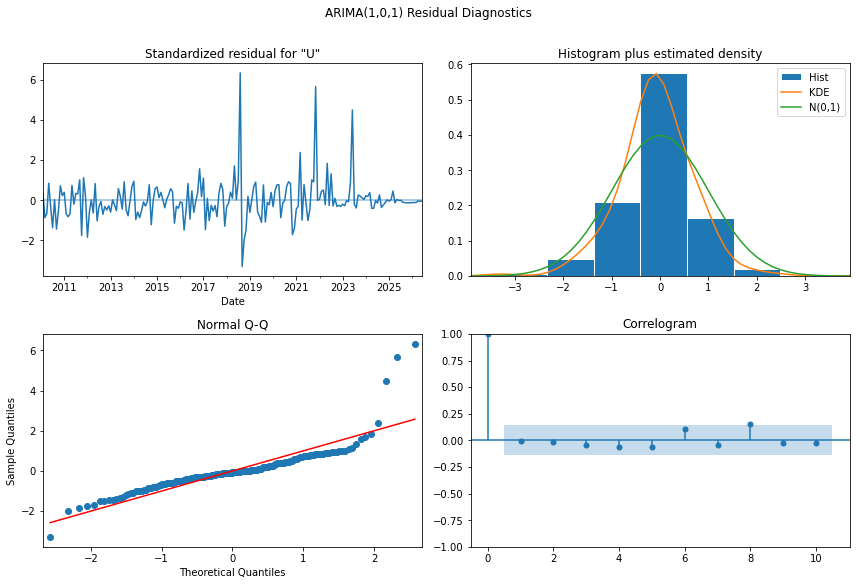

In [8]:
# 7. Residual diagnostics
model_fit.plot_diagnostics(figsize=(12, 8))
plt.suptitle('ARIMA(1,0,1) Residual Diagnostics', y=1.01)
plt.tight_layout()
plt.show()

In [9]:
# 8. 3-Month Forecast
forecast_steps = 3
final_forecast_obj = model_fit.get_forecast(steps=forecast_steps)
final_forecast_df = final_forecast_obj.summary_frame()

# Revert log-returns back to actual price scale
last_price = df_m['USDTRY'].iloc[-1]
final_prices = []
conf_lower = []
conf_upper = []
cumulative_log_val = 0

for i, row in final_forecast_df.iterrows():
    cumulative_log_val += row['mean']
    final_prices.append(last_price * np.exp(cumulative_log_val))
    conf_lower.append(last_price * np.exp(cumulative_log_val - 1.96 * row['mean_se']))
    conf_upper.append(last_price * np.exp(cumulative_log_val + 1.96 * row['mean_se']))

forecast_dates = pd.date_range(start=df_m.index[-1], periods=forecast_steps + 1, freq='MS')[1:]
final_prediction_table = pd.DataFrame({
    'Forecast USD/TRY': final_prices,
    'Lower 95% CI': conf_lower,
    'Upper 95% CI': conf_upper
}, index=forecast_dates)

print("--- 3-MONTH USD/TRY EXCHANGE RATE FORECAST ---")
print(final_prediction_table.round(4))

--- 3-MONTH USD/TRY EXCHANGE RATE FORECAST ---
            Forecast USD/TRY  Lower 95% CI  Upper 95% CI
2026-07-01           47.3570       43.1800       51.9382
2026-08-01           48.1928       43.9178       52.8840
2026-09-01           49.0412       44.6900       53.8161


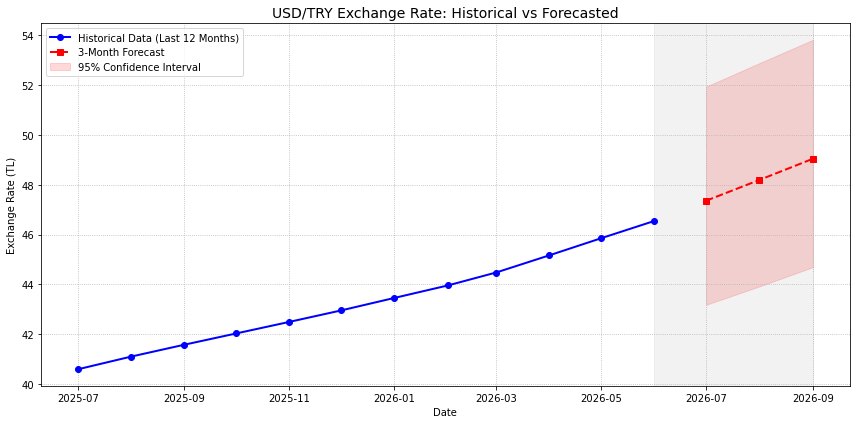

In [10]:
# 9. Final visualization with confidence intervals

import matplotlib.pyplot as plt
import numpy as np

actual_data_tail = df_m['USDTRY'].tail(12)


x_hist = actual_data_tail.index.to_numpy()
y_hist = actual_data_tail.to_numpy()

x_forecast = final_prediction_table.index.to_numpy()
y_forecast = final_prediction_table["Forecast USD/TRY"].to_numpy()

lower = final_prediction_table["Lower 95% CI"].to_numpy()
upper = final_prediction_table["Upper 95% CI"].to_numpy()

plt.figure(figsize=(12,6))

# Historical data
plt.plot(
    x_hist,
    y_hist,
    color="blue",
    marker="o",
    linewidth=2,
    label="Historical Data (Last 12 Months)"
)

# Forecast
plt.plot(
    x_forecast,
    y_forecast,
    color="red",
    linestyle="--",
    marker="s",
    linewidth=2,
    label="3-Month Forecast"
)

# Confidence interval
plt.fill_between(
    x_forecast,
    lower,
    upper,
    color="red",
    alpha=0.15,
    label="95% Confidence Interval"
)

# Forecast area
plt.axvspan(
    x_hist[-1],
    x_forecast[-1],
    color="gray",
    alpha=0.10
)

plt.title("USD/TRY Exchange Rate: Historical vs Forecasted", fontsize=14)
plt.xlabel("Date")
plt.ylabel("Exchange Rate (TL)")
plt.grid(True, linestyle=":")
plt.legend()

plt.tight_layout()
plt.show()